# Seaborn

## Overview

Seaborn is a high-level visualization library built on top of Matplotlib. It gives you cleaner defaults and concise plotting functions for statistical graphics, while still letting you use Matplotlib for fine-grained control. Pandas plotting is excellent for fast, direct plotting from a `DataFrame`. Seaborn becomes stronger when you need **semantic mappings** (color/style/size by variables), cleaner statistical defaults, and grouped comparisons.

Practical rules:
- Start with **Pandas** for quick checks.
- Use **Seaborn** for statistical/grouped visuals.
- Drop to **Matplotlib** when you need exact low-level control.

As a comparison between the three visualization libraries:

Practical rules:
- Start with Pandas for quick checks.
- Use **Seaborn** for **statistical/grouped** visuals.
- Drop to Matplotlib when you need exact low-level control.

In this notebook, we will use the following learning path:

1. Quick start (first useful plots)
2. Data model and semantic mappings (`hue`, `style`, `size`)
3. Core seaborn plot families (distribution, relational, categorical)
4. Figure-level wrappers and faceting (`displot`, `relplot`, `catplot`)
5. Multivariate views (`pairplot`, `jointplot`, `heatmap`)
6. Optional KDE internals appendix


By convention, Seaborn is imported as `sns`:

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %pip install seaborn
import seaborn as sns

# Set consistent defaults for all following plots
sns.set_theme(style='whitegrid', context='notebook')

tips = sns.load_dataset('tips')
planets = sns.load_dataset('planets')
iris = sns.load_dataset('iris')
penguins = sns.load_dataset('penguins')

### Quick Comparison: Why Seaborn?

#### Seaborn vs. Pandas

Compare the two plots in the next cells and you shall see that seaborn is giving more information about the data:

- Top plot (`pd.plot.scatter()`): fast DataFrame-first plotting.
- Bottom plot (`sns.scatterplot()`): semantic mappings (`hue`, `style`, `size`) with cleaner statistical **defaults**.

Style note: this plot uses the global theme set earlier with `sns.set_theme(style='whitegrid', context='notebook')`.


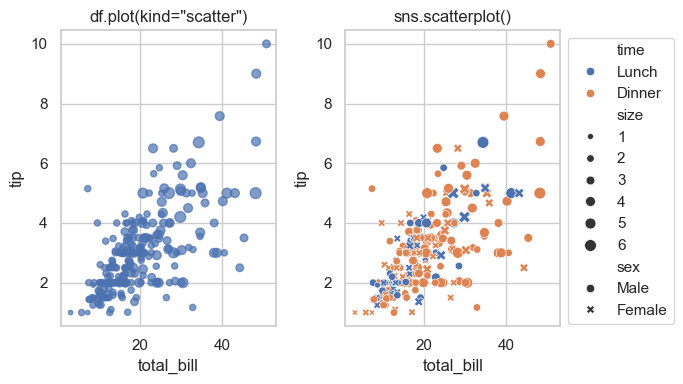

In [89]:
fig, ax = plt.subplots(1, 2, figsize=(7, 4))

# Pandas: fast DataFrame-first plotting
tips.plot(
    kind='scatter',
    x='total_bill', y='tip',
    s=tips['size']*10,          ### s, not size, for scatter plot marker size
    alpha=0.7,                  ### add some transparency for better visibility
    ax=ax[0],
    title='df.plot(kind="scatter")',
)
# Seaborn: more flexible, but requires more code
sns.scatterplot(
    data=tips,
    x='total_bill', y='tip',
    hue='time', 
    style='sex', 
    size='size',
    ax=ax[1]
)
ax[1].set_title('sns.scatterplot()')
ax[1].legend(bbox_to_anchor=(1, 1))  ### move legend outside the plot
plt.tight_layout()


#### Plotting Methods Example

Let's start with a few axes-level examples. This gives you a fast way to recognize seaborn syntax before diving into API details. Here we see three different plotting functions of seaborn: `histplot()`, `scatterplot()`, and `boxplot()`. 


Let's take a look at the `tips` dataset.

In [90]:
tips.loc[:, ['total_bill', 'tip', 'size', 'day', 'time', 'sex']].head()

,total_bill,tip,size,day,time,sex
0,16.99,1.01,2,Sun,Dinner,Female
1,10.34,1.66,3,Sun,Dinner,Male
2,21.01,3.50,3,Sun,Dinner,Male
3,23.68,3.31,2,Sun,Dinner,Male
4,24.59,3.61,4,Sun,Dinner,Female


Using the MPL `subplots()` function, you can place the plots side-by-side. You can see that the seaborn syntax for calling the plotting functions is familiar but the method names are different. Here we have one plot created by MPL and three by seaborn. 

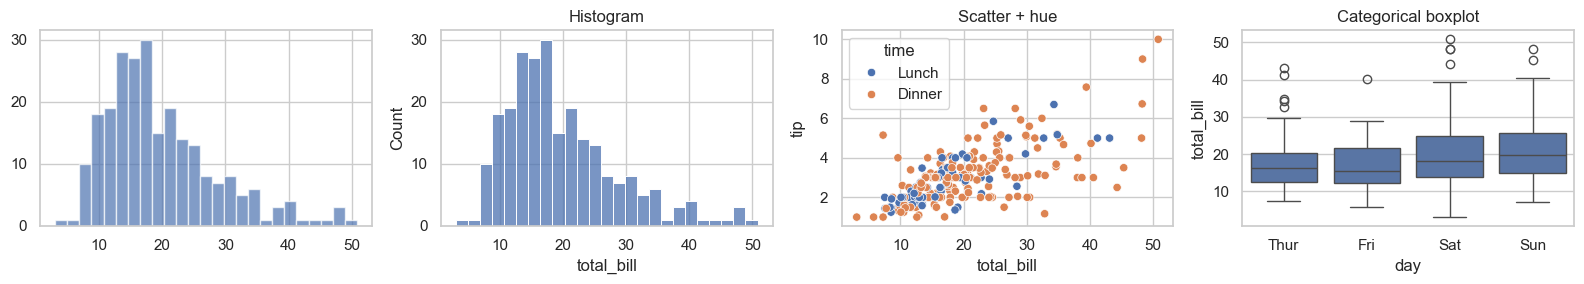

In [91]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3))

### Matplotlib: more flexible, but requires more code
ax[0].hist(tips['total_bill'], bins=25, alpha=0.7)

### Seaborn
sns.histplot(data=tips, x='total_bill', bins=25, ax=ax[1])
ax[1].set_title('Histogram')

### Seaborn with hue
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', ax=ax[2])
ax[2].set_title('Scatter + hue')

### Seaborn categorical plot
sns.boxplot(data=tips, x='day', y='total_bill', ax=ax[3])
ax[3].set_title('Categorical boxplot')

plt.tight_layout()


## Seaborn Data Model and Semantic Mappings

Seaborn works best with **tidy (long-form) data**:
- each column is a variable
- each row is one observation

Common semantic mappings:
- `hue`: map category/value to color
- `style`: map category to marker or line style
- `size`: map numeric values to marker size

Important distinction:
- Use `size=...` to map from data
- Use `s=...` for a constant marker size


### Data Formats

Data can be structured in different ways. Understanding these formats is essential because most Python visualization and analysis libraries, including Seaborn and pandas, expect data in a specific format. The common data formats are tidy, wide, and nested. 

| Format | Best For |
|--------|----------|
| Tidy | Seaborn, statsmodels, most analysis |
| Wide | Excel, quick inspection, some ML models |
| Nested | Raw API/JSON data before processing |

In practice, data often arrives in wide or nested format and should be converted to tidy before visualization or analysis. For example, `sns.barplot(data=df, x='category', y='value')` assumes each row is one observation. If your DataFrame is wide (one column per category), Seaborn won't work as expected and students will get confusing errors. So the practical point is: if a Seaborn plot looks wrong or throws an error, check whether your DataFrame is in tidy format first — and if not, use `pd.melt()` to reshape it.

### Tidy (Long) Format

In tidy data, 

- **each row is one observation**, 
- **each column is one variable**, and 
- **each cell holds one value**. 
 
This is the preferred format for analysis and visualization.

In [92]:
import pandas as pd

tidy = pd.DataFrame({
    'student': ['Alice', 'Alice', 'Bob', 'Bob'],
    'subject': ['math', 'english', 'math', 'english'],
    'score':   [90, 85, 78, 88]
})
tidy

,student,subject,score
0,Alice,math,90
1,Alice,english,85
2,Bob,math,78
3,Bob,english,88


### Wide Format

In wide data, 

- each row represents one subject, and 
- variables are spread across multiple columns. 
 
This format is easier for humans to read at a glance.

In [93]:
wide = pd.DataFrame({
    'student': ['Alice', 'Bob'],
    'math':    [90, 78],
    'english': [85, 88]
})
wide

,student,math,english
0,Alice,90,85
1,Bob,78,88


### Nested Format

Nested data stores values inside **dictionaries** or **lists**, common when loading from JSON or APIs. It must be flattened before use.

In [94]:
nested = {
    'Alice': {'math': 90, 'english': 85},
    'Bob':   {'math': 78, 'english': 88}
}
nested

{'Alice': {'math': 90, 'english': 85}, 'Bob': {'math': 78, 'english': 88}}

### Converting Formats

In [95]:
students = pd.DataFrame({
    'student': ['Alice', 'Bob', 'Carol', 'David', 'Eve'],
    'gender':  ['F', 'M', 'F', 'M', 'F'],
    'grade':   [10, 10, 11, 11, 12],
    'math':    [90, 78, 85, 72, 95],
    'english': [85, 88, 80, 76, 92],
    'science': [92, 80, 88, 70, 96]
})
print("Wide DataFrame:")
print(students, "\n")

# Wide --> Tidy
tidy = pd.melt(students, 
               id_vars=['student', 'gender', 'grade'],
               var_name='subject', 
               value_name='score')
print("Tidy DataFrame:")
print(tidy)

# Tidy --> Wide
wide = tidy.pivot(index='student',
                  columns='subject', values='score')

# Nested --> Tidy
# Cleaner Nested --> Tidy conversion
flat = pd.DataFrame(nested).T.reset_index()
flat.columns = ['student'] + list(flat.columns[1:])
flat = pd.melt(flat, id_vars='student',
               var_name='subject', value_name='score')

Wide DataFrame:
  student gender  grade  math  english  science
0   Alice      F     10    90       85       92
1     Bob      M     10    78       88       80
2   Carol      F     11    85       80       88
3   David      M     11    72       76       70
4     Eve      F     12    95       92       96 

Tidy DataFrame:
   student gender  grade  subject  score
0    Alice      F     10     math     90
1      Bob      M     10     math     78
2    Carol      F     11     math     85
3    David      M     11     math     72
4      Eve      F     12     math     95
5    Alice      F     10  english     85
6      Bob      M     10  english     88
7    Carol      F     11  english     80
8    David      M     11  english     76
9      Eve      F     12  english     92
10   Alice      F     10  science     92
11     Bob      M     10  science     80
12   Carol      F     11  science     88
13   David      M     11  science     70
14     Eve      F     12  science     96


## Figure vs. Axes-Level APIs

Seaborn has two common usage patterns:

- **Figure-level** functions (e.g., `displot`, `relplot`, `catplot`) manage an entire figure/grid and return grid objects (`FacetGrid`, `JointGrid`, `PairGrid`).
- **Axes-level** functions (e.g., `histplot`, `scatterplot`, `lineplot`, `boxplot`) draw on a specific Matplotlib `ax` and return an `Axes`. In other words, axes-level functions make self-contained plots.

Rule of thumb:
- Use figure-level when **faceting** is the main goal.
- Use axes-level for **custom** subplot composition.


<!-- <figure>
    <img src="../../images/sns_plot_chart.png" alt="Seaborn Plots Chart" width=400 >
    <figcaption><a src="https://seaborn.pydata.org/tutorial/function_overview.html">Seaborn Plots Chart</a></figcaption>
<figure> -->
```{figure} ../../images/sns_plot_chart.png 
:name: sns_plot_chart
:width: 375
:align: center
:alt: Seaborn Plots Chart
Seaborn Plots [Chart](https://seaborn.pydata.org/tutorial/function_overview.html)
``` 

The syntax for using seaborn is:

```python
sns.PLOT-TYPE(data=df, x='col_a', y='col_b', hue='col_c')
      ↑           ↑         ↑          ↑          ↑
   plot type   DataFrame  x-axis     y-axis     color by
```

The table below summarizes common figure-level functions and their typical axes-level backends.

### API Differences
| Aspect | Figure-level | Axes-level |
|---|---|---|
| **Returns** | `FacetGrid` · `JointGrid` · `PairGrid` | `Axes` |
| **Faceting** | Built-in via `row=`, `col=`, `col_wrap=` | Not available — use `plt.subplots()` + loop |
| **Sizing** | `height=` + `aspect=` | `plt.subplots(figsize=(w, h))` |
| **Multiple panels** | Automatic grid from data | `fig, axes = plt.subplots()` + pass `ax=` |
| **Layering plots** | ✗ Hard | ✓ Easy — multiple functions on same `ax` |
| **When to use** | Grouped/faceted views, small multiples | Custom layouts, overlaying, single-axes control |

### Function Reference

| Figure-level | Axes-level Functions | Typical use |
|---|---|---|
| `displot()` | `histplot()`, `kdeplot()`, `ecdfplot()` | Distributions, histograms, KDE, ECDF |
| `relplot()` | `scatterplot()`, `lineplot()` | Relationships and trends |
| `catplot()` | `stripplot()`, `swarmplot()`, `boxplot()`, `violinplot()`, `boxenplot()`, `barplot()`, `countplot()`, `pointplot()` | Categorical comparisons |
| `jointplot()` | `scatterplot()`, `kdeplot()`, `histplot()`, `regplot()`, `residplot()`, `kind="hex"` *(Matplotlib hexbin)* | Bivariate plots with marginals and/or regression |
| `pairplot()` | `scatterplot()`, `kdeplot()`, `histplot()` | Pairwise relationships across variables |


## Distribution Plots

Distribution plots help you understand spread, skew, and shape of numerical variables. 


### Histogram

A histogram groups values into **bins** and shows **frequency** in each bin. Note this is an axes level function and you use **ax** to catch the created plot.


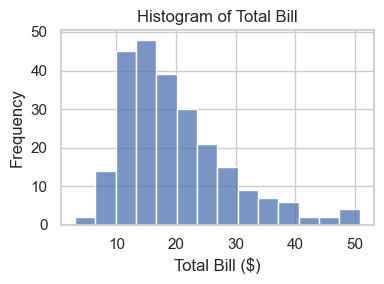

In [96]:
ax = sns.histplot(data=tips, x='total_bill')    ### sns.PLOT-TYPE(data=df, x='col_a', y='col_b', hue='col_c')
ax.set_title('Histogram of Total Bill')
ax.set_xlabel('Total Bill ($)')
ax.set_ylabel('Frequency')  
ax.figure.set_size_inches(4, 3)
plt.tight_layout()

To control size, create an axes with Matplotlib and pass `ax=`:

<Axes: xlabel='total_bill', ylabel='Count'>

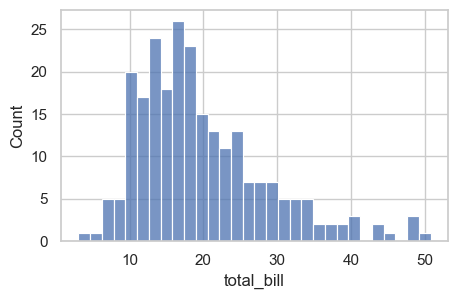

In [97]:
fig, axes = plt.subplots(figsize=(5, 3))
sns.histplot(data=tips, x='total_bill', bins=30, ax=axes)


#### Comparing Libraries

Compare histogram APIs across pandas, Matplotlib, and seaborn:

- pandas: DataFrame-oriented convenience
- Matplotlib: lower-level direct control
- seaborn: statistical defaults and cleaner styling


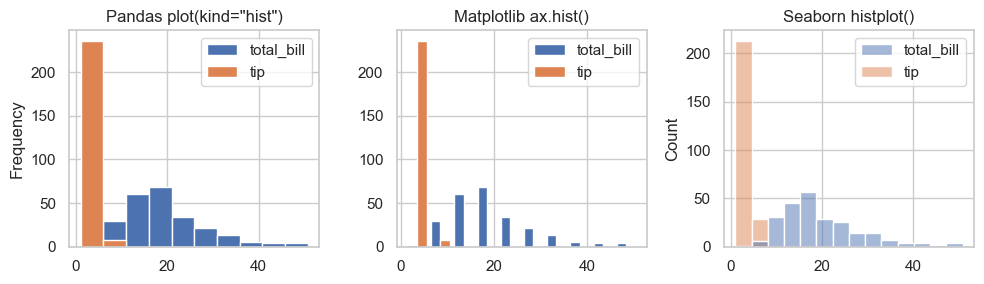

In [98]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

data = tips[['total_bill', 'tip']]

### Pandas histogram
data.plot(kind='hist', title='Pandas plot(kind="hist")', ax=ax[0])

### Matplotlib histogram
ax[1].hist(data, label=['total_bill', 'tip'])
ax[1].set_title('Matplotlib ax.hist()')
ax[1].legend()

### Seaborn histogram
sns.histplot(data=data, ax=ax[2])
ax[2].set_title('Seaborn histplot()')

plt.tight_layout()


In [99]:
### Exercise: Histogram for Total Bill
#   1. Create a figure and axes with figsize=(5, 3).
#   2. Plot a histogram of tips['total_bill'] using sns.histplot.
#   3. Use bins=20.
#   4. Set the title to 'Total Bill Distribution'.
### Your code starts here.




### Your code ends here.


Text(0.5, 1.0, 'Total Bill Distribution')

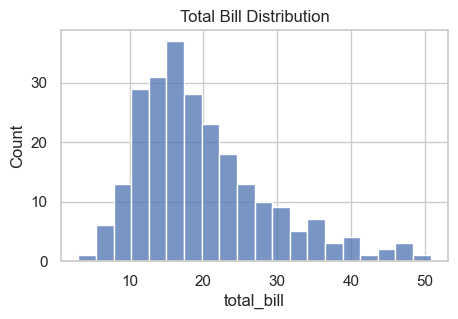

In [100]:
### Solution
fig, ax = plt.subplots(figsize=(5, 3))
sns.histplot(data=tips, x='total_bill', bins=20, ax=ax)
ax.set_title('Total Bill Distribution')


#### Bins, Alpha, and KDE

Three common controls:
- `bins`: granularity of histogram bars
- `alpha`: transparency
- `kde=True`: overlay smooth density estimate


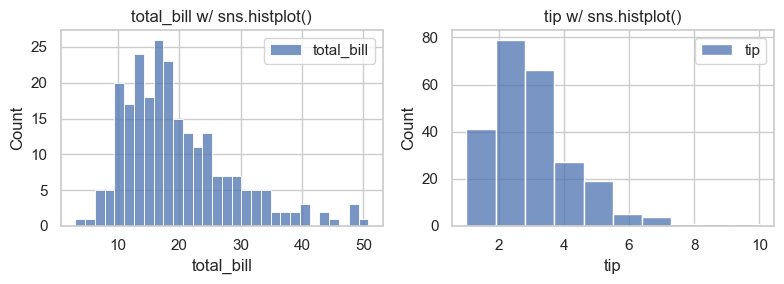

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
bins = [30, 10]
for i, col in enumerate(data.columns):
    sns.histplot(data[col], bins=bins[i], label=col, ax=axes[i])
    axes[i].set_title(f'{col} w/ sns.histplot()')
    axes[i].legend()
plt.tight_layout()


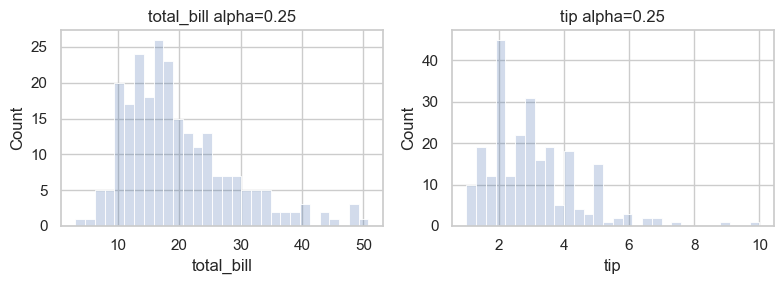

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, col in enumerate(data.columns[:2]):
    sns.histplot(data[col], alpha=0.25, bins=30, ax=axes[i])
    axes[i].set_title(f'{col} alpha=0.25')
plt.tight_layout()


To overlay KDE, set keyword argument `kde=True` when plotting.

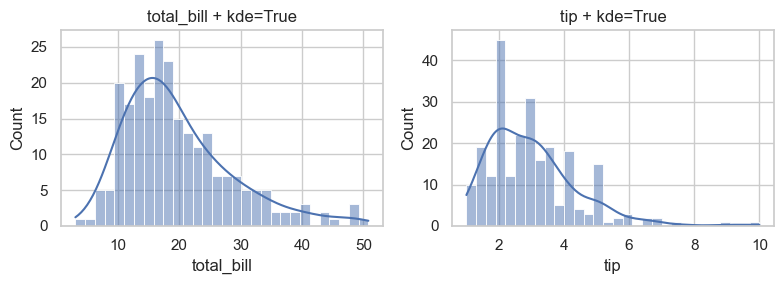

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, col in enumerate(data.columns):
    sns.histplot(data[col], alpha=0.5, bins=30, kde=True, ax=axes[i])  ### add kde=True for kernel density estimate overlay
    axes[i].set_title(f'{col} + kde=True')
plt.tight_layout()


In [104]:
### Exercise: Compare Histogram Settings
#   1. Create fig, axes = plt.subplots(1, 2, figsize=(8, 3)).
#   2. On axes[0], plot tips['tip'] with bins=10 and title 'bins=10'.
#   3. On axes[1], plot tips['tip'] with bins=30, alpha=0.4, kde=True,
#      and title 'bins=30, alpha=0.4, kde=True'.
#   4. Call plt.tight_layout().
### Your code starts here.




### Your code ends here.


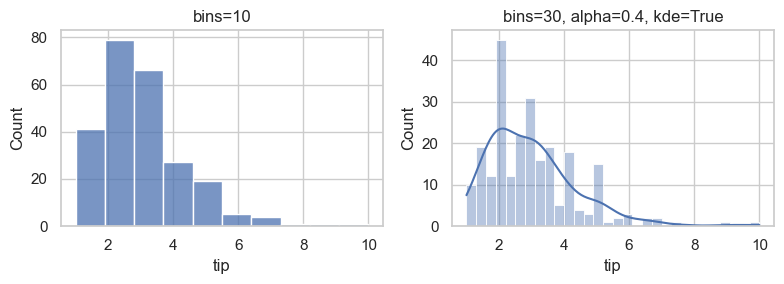

In [105]:
### Solution
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.histplot(tips['tip'], bins=10, ax=axes[0])
axes[0].set_title('bins=10')

sns.histplot(tips['tip'], bins=30, alpha=0.4, kde=True, ax=axes[1])
axes[1].set_title('bins=30, alpha=0.4, kde=True')

plt.tight_layout()


### KDE / Density

KDE is a smooth estimate of a distribution. It is often useful alongside histograms.


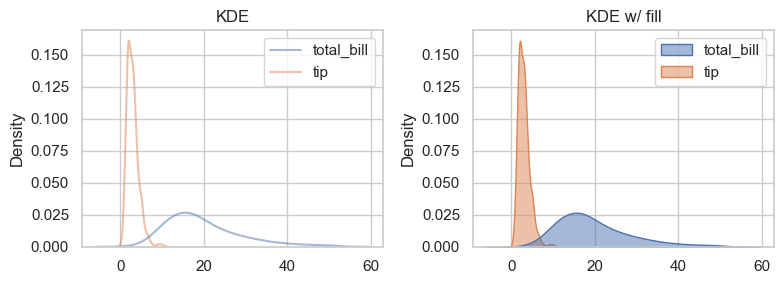

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.kdeplot(data=data, alpha=0.5, ax=axes[0])   ### seaborn ignores non-numeric columns, so no need to specify x or y
axes[0].set_title('KDE')

sns.kdeplot(data=data, alpha=0.5, ax=axes[1], fill=True)    ### add fill=True for filled KDE
axes[1].set_title('KDE w/ fill')

plt.tight_layout()


A 2D KDE is a smooth version of scatterplot.

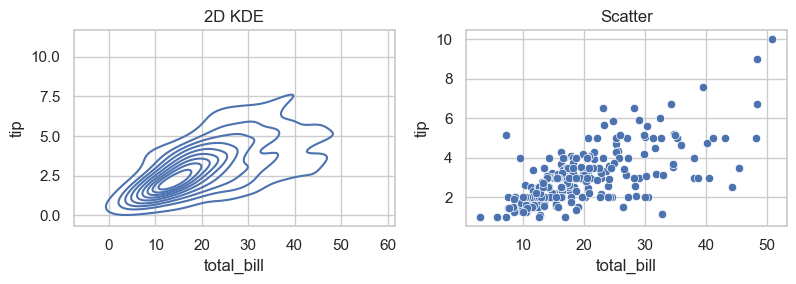

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.kdeplot(data=data, x='total_bill', y='tip', ax=axes[0])  ### specify x and y for 2D KDE
axes[0].set_title('2D KDE')

sns.scatterplot(data=data, x='total_bill', y='tip', ax=axes[1])
axes[1].set_title('Scatter')

plt.tight_layout()


Using density plot as an example of how Pandas visualization differs from Matplotlib and Seaborn:

| Library                | Function                | Notes                       |
| ---------------------- | ----------------------- | --------------------------- |
| **Seaborn**            | `sns.kdeplot()`         | most common, easy to use    |
| **Pandas**             | `.plot(kind="density")` | convenient for quick plots  |
| **Matplotlib + SciPy** | `gaussian_kde()`        | manual control over details |


In [108]:
### Exercise: KDE for Two Variables
#   1. Create fig, axes = plt.subplots(1, 2, figsize=(8, 3)).
#   2. On axes[0], draw sns.kdeplot for tips['total_bill'] with fill=True.
#   3. On axes[1], draw sns.kdeplot for tips['tip'] with fill=True.
#   4. Title the plots 'total_bill KDE' and 'tip KDE'.
#   5. Call plt.tight_layout().
### Your code starts here.




### Your code ends here.


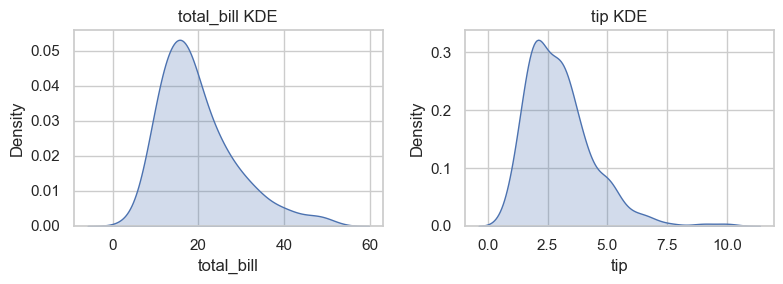

In [109]:
### Solution
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.kdeplot(tips['total_bill'], fill=True, ax=axes[0])
axes[0].set_title('total_bill KDE')

sns.kdeplot(tips['tip'], fill=True, ax=axes[1])
axes[1].set_title('tip KDE')

plt.tight_layout()


## Relational Plots

Relational plots show how variables move together (patterns, trends, clusters).


### Scatter Plot

<Axes: xlabel='total_bill', ylabel='tip'>

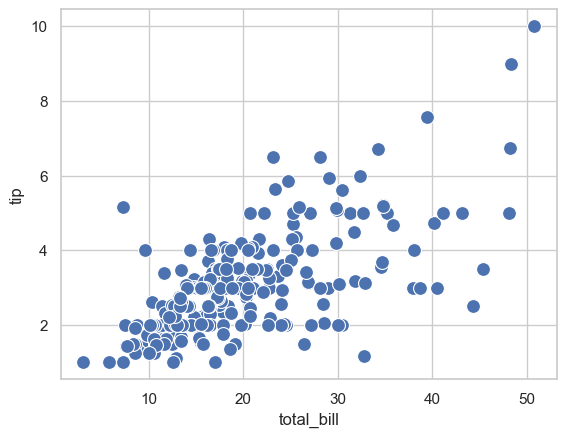

In [110]:
sns.scatterplot(x='total_bill', y='tip', data=tips, s=100, legend=True)

To control the figure size.

<Axes: xlabel='total_bill', ylabel='tip'>

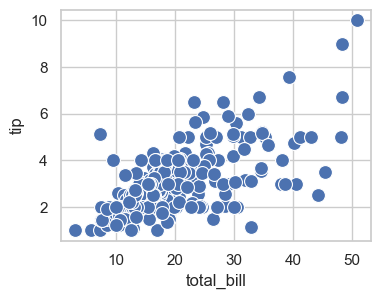

In [111]:
fig, axes = plt.subplots(figsize=(4, 3))
sns.scatterplot(x='total_bill', y='tip', data=tips, s=100, legend=True, ax=axes)

Add `hue=`

<Axes: xlabel='total_bill', ylabel='tip'>

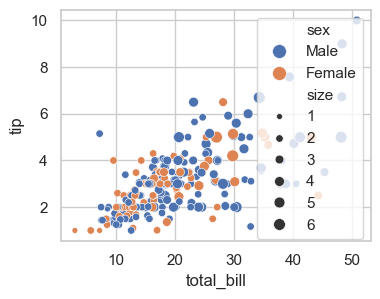

In [ ]:
fig, axes = plt.subplots(figsize=(4, 3))
sns.scatterplot(x='total_bill', y='tip', data=tips, s=100, legend=True, ax=axes, hue='sex')

Add size and move legend out of the plot `using bbox_to_anchor=`.

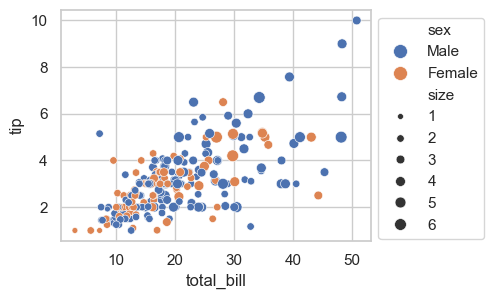

In [138]:
fig, axes = plt.subplots(figsize=(4, 3))
sns.scatterplot(x='total_bill', y='tip', data=tips, s=100, legend=True, ax=axes, hue='sex', size='size')
axes.legend(bbox_to_anchor=(1, 1))  ### move legend outside the plot

In [131]:
### Exercise: Scatter with Semantic Mapping
#   1. Create a scatter plot of total_bill vs tip.
#   2. Color points by time (hue='time').
#   3. Use marker size mapping from the 'size' column with sizes=(30, 180).
#   4. Set the title to 'Tips: Bill vs Tip by Time and Party Size'.
### Your code starts here.




### Your code ends here.


Text(0.5, 1.0, 'Tips: Bill vs Tip by Time and Party Size')

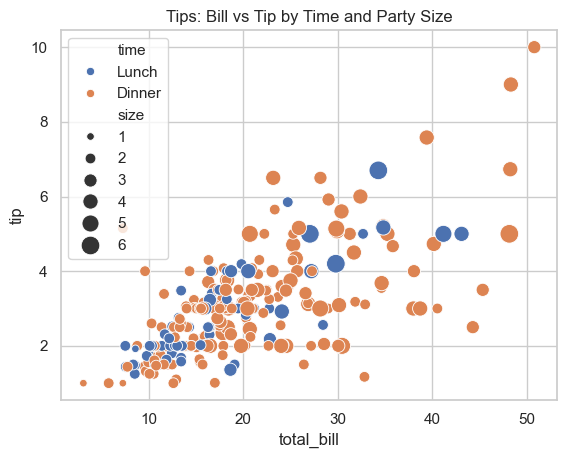

In [132]:
### Solution
ax = sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    sizes=(30, 180)
)
ax.set_title('Tips: Bill vs Tip by Time and Party Size')


### Line Plot

`lineplot` is commonly used for trends across an ordered x-axis. By default, seaborn aggregates repeated x values and can show uncertainty intervals.


<Axes: xlabel='day', ylabel='tip'>

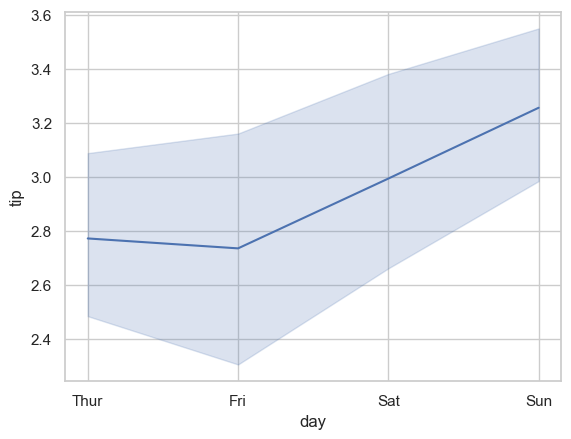

In [140]:
sns.lineplot(x='day', y='tip', data=tips, estimator='mean', errorbar=('ci', 95))

In [115]:
### Exercise: Average Tip by Day
#   1. Create a line plot with x='day' and y='tip' using the tips dataset.
#   2. Use estimator='mean'.
#   3. Keep a 95% confidence interval using errorbar=('ci', 95).
#   4. Set the title to 'Average Tip by Day'.
### Your code starts here.




### Your code ends here.


Text(0.5, 1.0, 'Average Tip by Day')

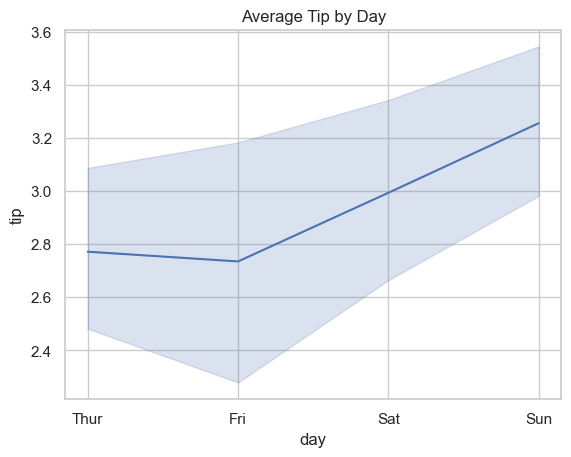

In [116]:
### Solution
ax = sns.lineplot(x='day', y='tip', data=tips, estimator='mean', errorbar=('ci', 95))
ax.set_title('Average Tip by Day')


## Categorical Plots

Categorical plots summarize or compare values across groups.


`sns.catplot()` is a figure-level wrapper for categorical plots (`kind='box'`, `'violin'`, `'bar'`, `'count'`, etc.).

Use it when you want consistent faceting/layout behavior across categorical plot types.


### Box Plot

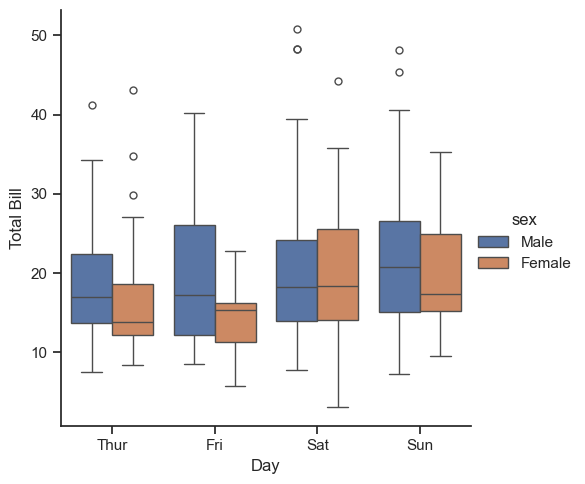

In [143]:
with sns.axes_style(style='ticks'):
    g = sns.catplot(data=tips, x='day', y='total_bill', hue='sex', kind='box')
    g.set_axis_labels('Day', 'Total Bill')


In [118]:
### Exercise: Box Plot by Day and Sex
#   1. Use sns.catplot with kind='box'.
#   2. Plot x='day', y='total_bill', and hue='sex' from tips.
#   3. Set axis labels to 'Day' and 'Total Bill'.
### Your code starts here.




### Your code ends here.


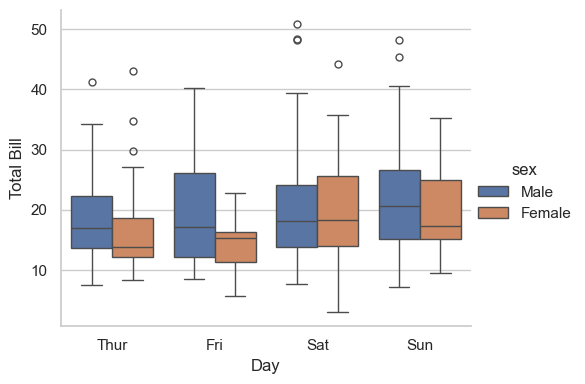

In [119]:
### Solution
g = sns.catplot(x='day', y='total_bill', hue='sex', data=tips, kind='box', height=4, aspect=1.25)
g.set_axis_labels('Day', 'Total Bill')


### Bar Plot

`bar` shows an **estimator** (mean by default) with uncertainty intervals. 
Also, here 

- Instead of using `subplots()`, we save the plot, which is an axes, and then control the styling directly. 
- the `with` statement: The with statement temporarily applies a style only for the plots created inside its block. Once the block ends, Seaborn returns to the previous style — nothing is permanently changed.


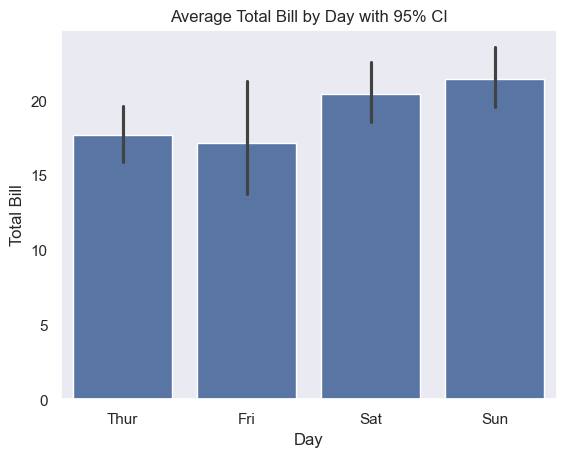

In [152]:
with sns.axes_style(style='dark'):
    g = sns.barplot(data=tips, x='day', y='total_bill', errorbar=('ci', 95))
    g.set_xlabel('Day')
    g.set_ylabel('Total Bill')
    g.set_title('Average Total Bill by Day with 95% CI')


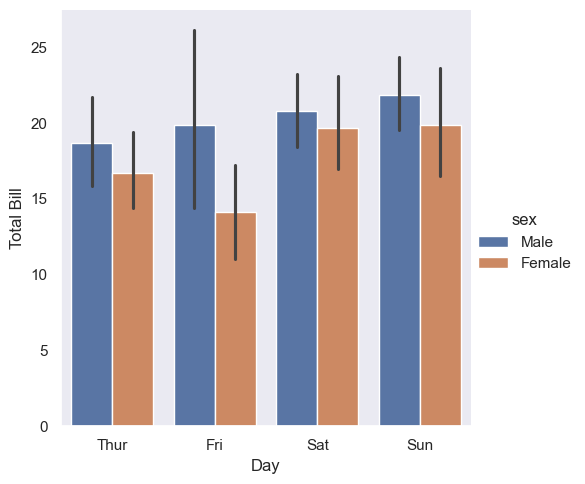

In [153]:
with sns.axes_style(style='dark'):
    g = sns.catplot(data=tips, x='day', y='total_bill', hue='sex', kind='bar', errorbar=('ci', 95))
    g.set_axis_labels('Day', 'Total Bill')


In [ ]:
### Exercise: Mean Total Bill by Day
#   1. Create a categorical bar plot with x='day' and y='total_bill'.
#   2. Use kind='bar' and errorbar=('ci', 95).
#   3. Set axis labels to 'Day' and 'Total Bill'.
### Your code starts here.




### Your code ends here.


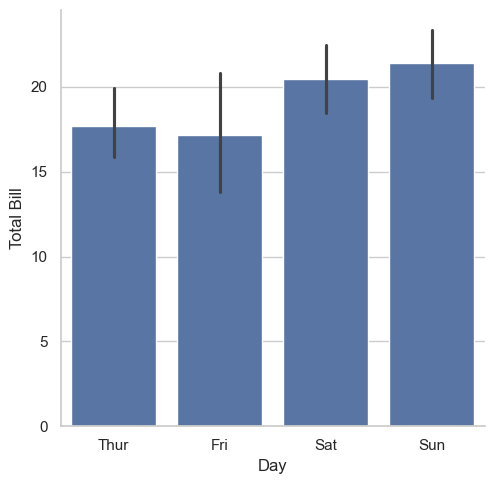

In [ ]:
### Solution
g = sns.catplot(x='day', y='total_bill', data=tips, kind='bar', errorbar=('ci', 95))
g.set_axis_labels('Day', 'Total Bill')


### Count Plot (`kind='count'`)

Count plots show category frequencies. This is different from histograms, which bin continuous numeric values.


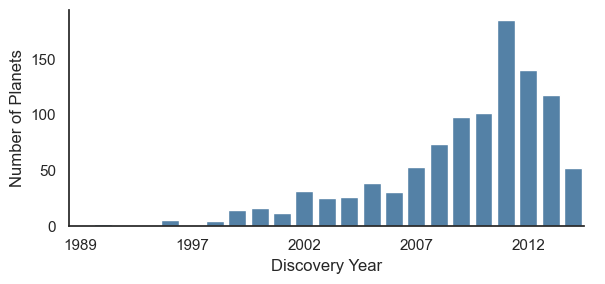

In [160]:
with sns.axes_style('white'):       ### with for temporary style
    g = sns.catplot(
        data=planets,
        x='year',
        aspect=2,
        kind='count',
        color='steelblue',
        height=3
    )
    g.set_xticklabels(step=5)
    g.set_axis_labels('Discovery Year', 'Number of Planets')  ### instead of column labels, we can set custom axis labels



In [ ]:
### Exercise: Count Planets Discoveries by Year
#   1. Create a count plot using planets with x='year'.
#   2. Use kind='count', height=3, aspect=2, and color='steelblue'.
#   3. Set x tick labels to show every 5th year.
### Your code starts here.




### Your code ends here.


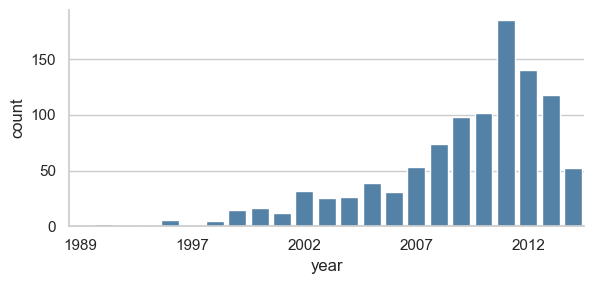

In [ ]:
### Solution
g = sns.catplot(
    x='year',
    data=planets,
    kind='count',
    height=3,
    aspect=2,
    color='steelblue'
)
g.set_xticklabels(step=5)


## Figure-Level Wrappers and Faceting

Use figure-level wrappers when you want seaborn to build panel grids directly from grouping variables.


These wrappers make small-multiple comparisons much easier (`row=`, `col=`, `hue=`, `height=`, `aspect=`).


#### `displot()`

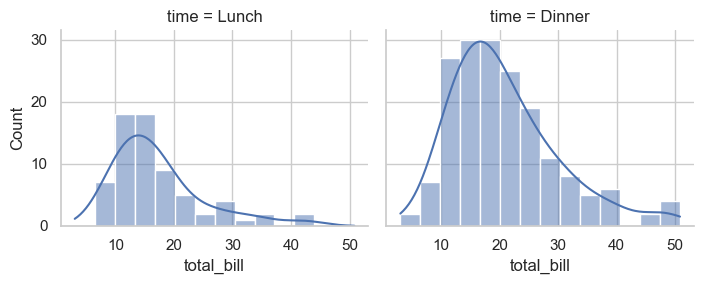

In [163]:
sns.displot(data=tips, x='total_bill', col='time', kde=True, height=3, aspect=1.2)

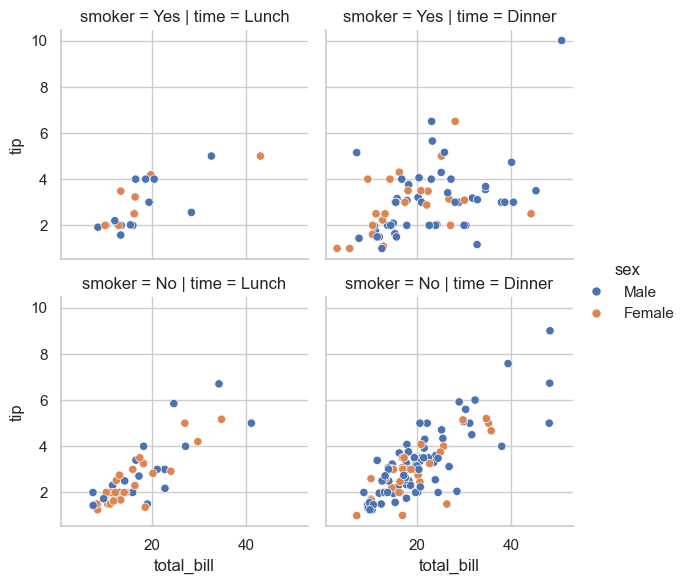

In [164]:
sns.relplot(
    data=tips,
    x='total_bill', y='tip',
    hue='sex', col='time', row='smoker',
    kind='scatter', height=3, aspect=1
)

### `catplot()`

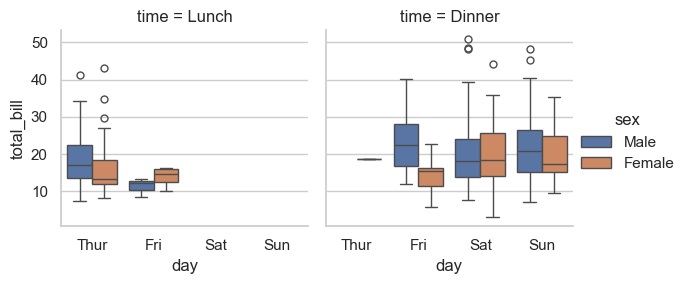

In [ ]:
sns.catplot(
    data=tips,
    x='day', y='total_bill', hue='sex', col='time',
    kind='box', height=3, aspect=1
)

### FacetGrid

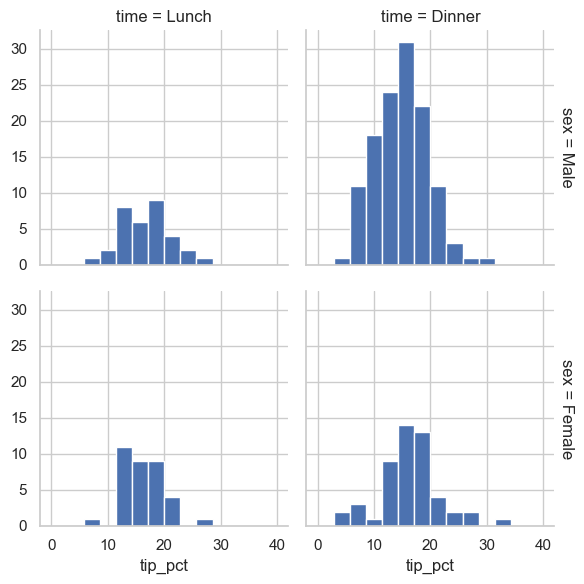

In [ ]:
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']

grid = sns.FacetGrid(data=tips, row='sex', col='time', margin_titles=True)
grid.map(plt.hist, 'tip_pct', bins=np.linspace(0, 40, 15))


In [ ]:
### Exercise: Faceted Tip Percentage Histograms
#   1. Create tips['tip_pct'] as 100 * tip / total_bill.
#   2. Build a FacetGrid with row='sex' and col='time'.
#   3. Map plt.hist on 'tip_pct' using bins=np.linspace(0, 40, 15).
### Your code starts here.




### Your code ends here.


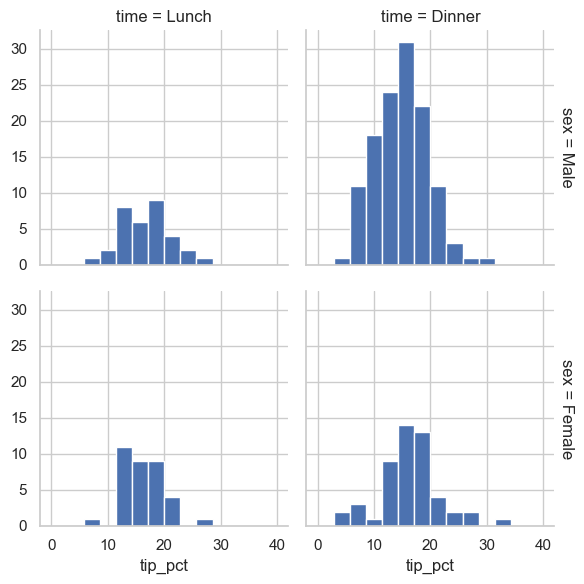

In [ ]:
### Solution
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']
grid = sns.FacetGrid(data=tips, row='sex', col='time', margin_titles=True)
grid.map(plt.hist, 'tip_pct', bins=np.linspace(0, 40, 15))


## Multivariate Views

These plots help you inspect relationships among multiple variables at once.


### Pair Plots

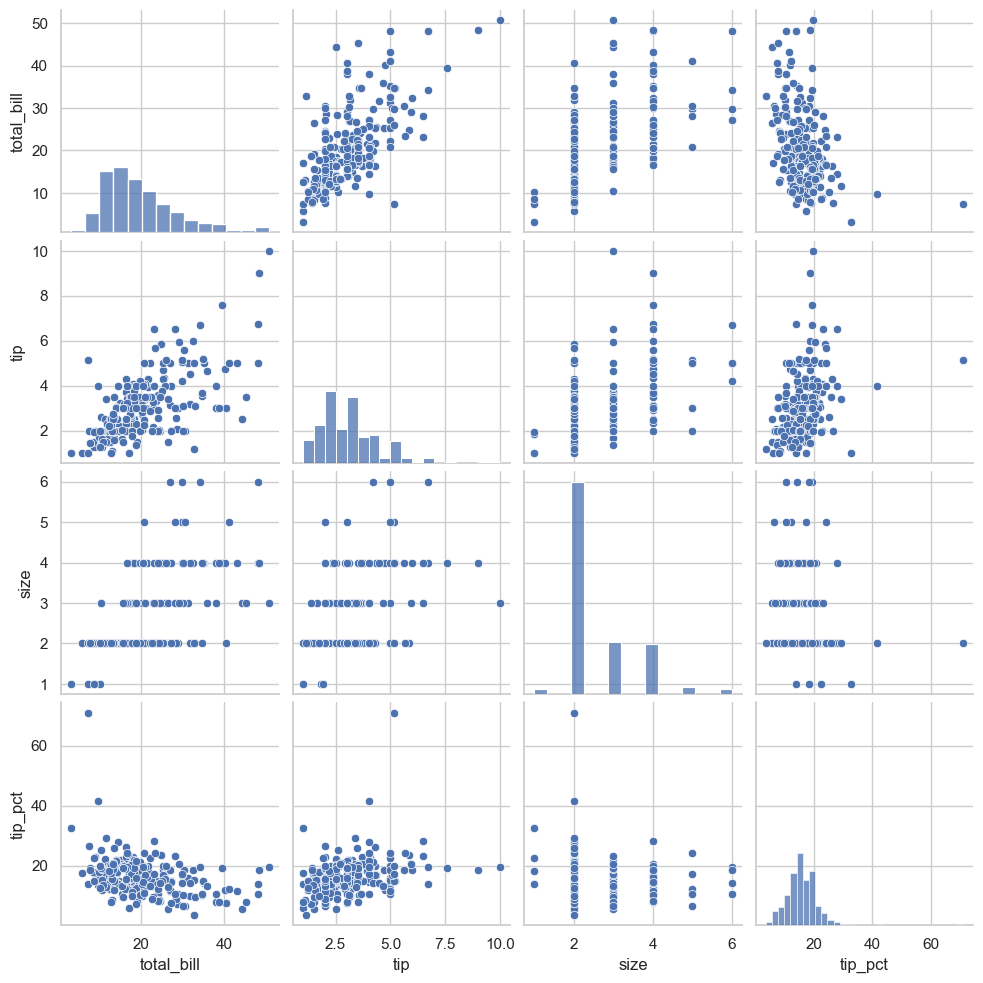

In [ ]:
sns.pairplot(tips)

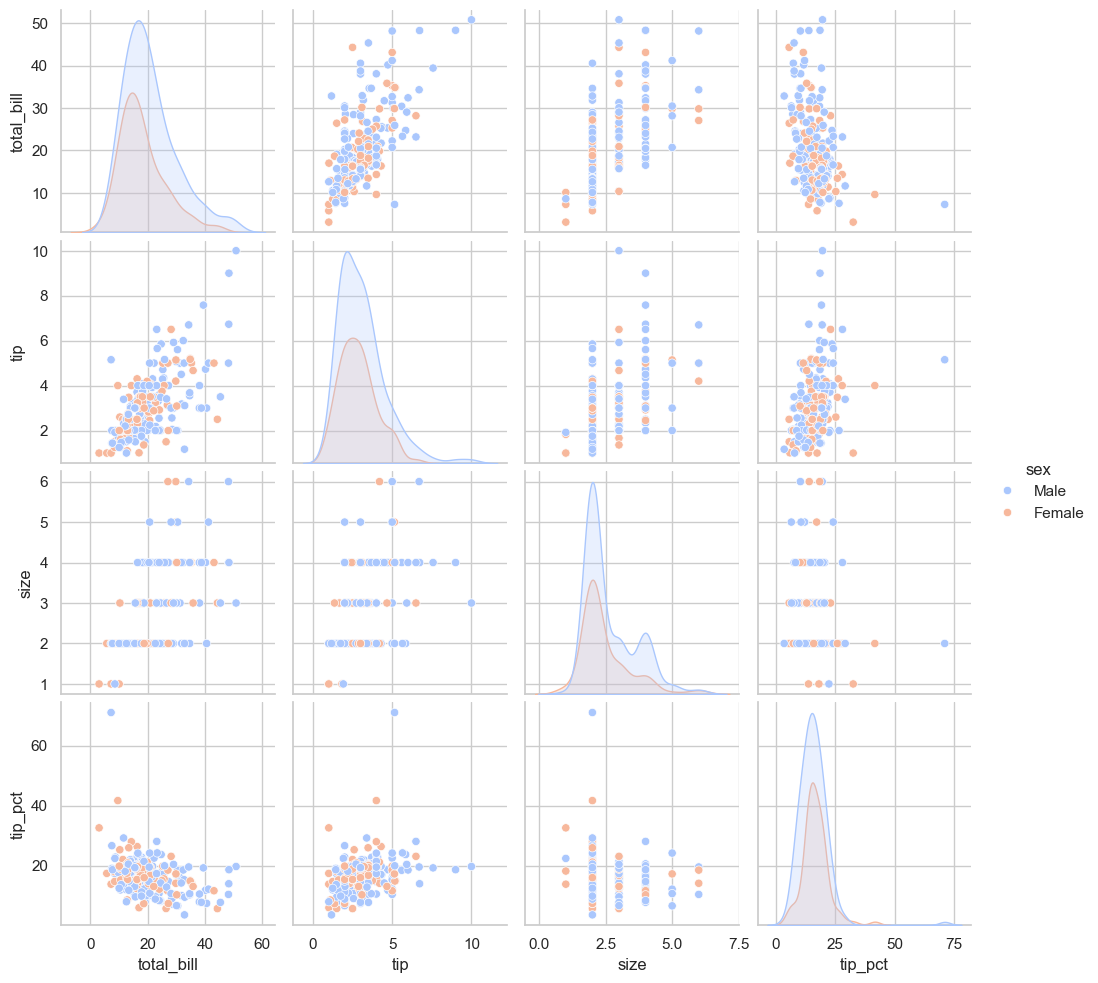

In [ ]:
sns.pairplot(tips, hue='sex', palette='coolwarm')

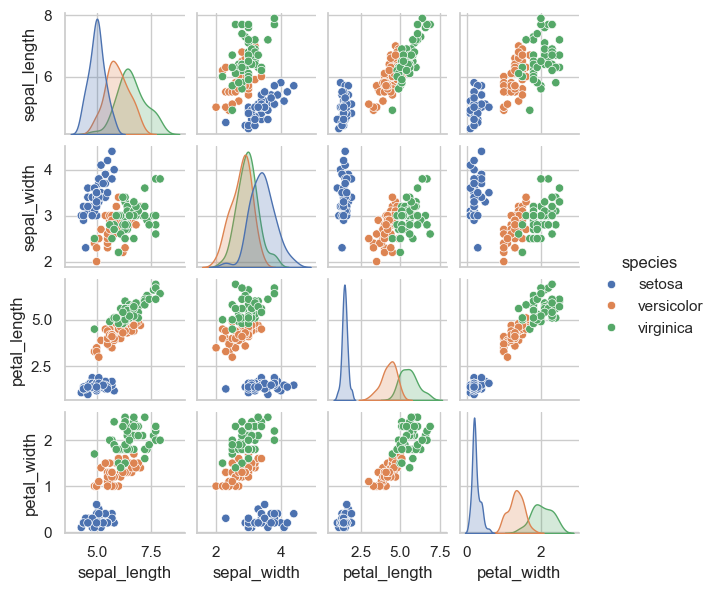

In [ ]:
sns.pairplot(iris, hue='species', height=1.5)

In [ ]:
### Exercise: Pairplot with Group Coloring
#   1. Create a pairplot using the iris dataset.
#   2. Color points by species using hue='species'.
#   3. Set height=1.5 for each subplot.
### Your code starts here.




### Your code ends here.


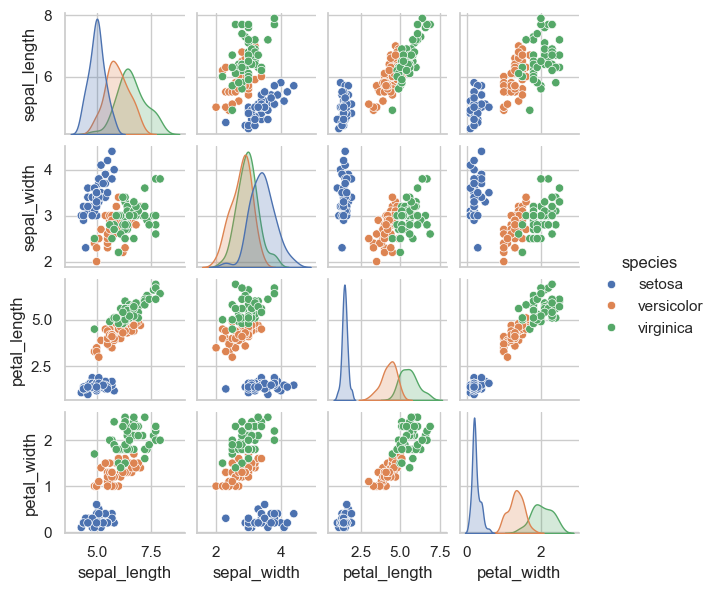

In [ ]:
### Solution
sns.pairplot(iris, hue='species', height=1.5)


### Joint Plots

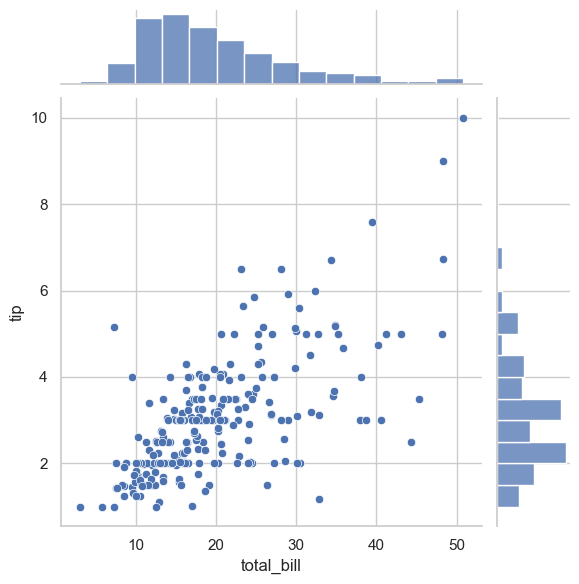

In [165]:
sns.jointplot(data=tips, x='total_bill', y='tip', kind='scatter')

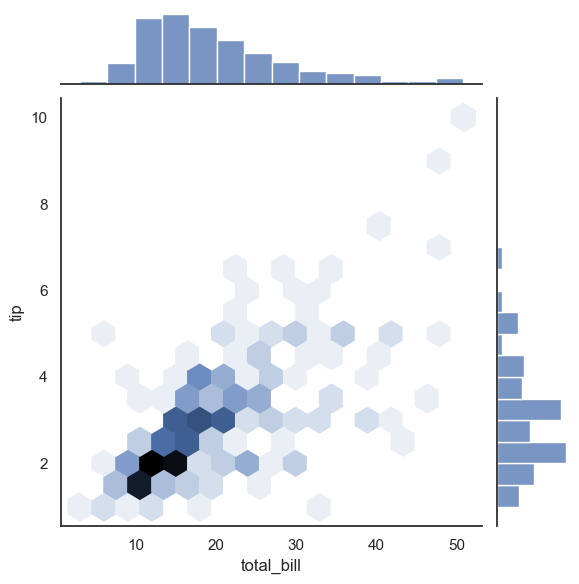

In [166]:
with sns.axes_style('white'):
    sns.jointplot(x='total_bill', y='tip', data=tips, kind='hex')


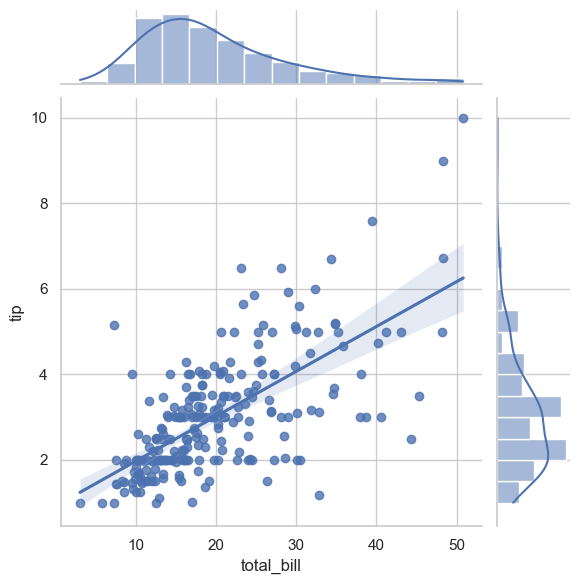

In [167]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='reg')

In [ ]:
### Exercise: Joint Plot with Regression
#   1. Create a joint plot of total_bill vs tip from tips.
#   2. Use kind='reg'.
#   3. Keep default marginal distributions.
### Your code starts here.




### Your code ends here.


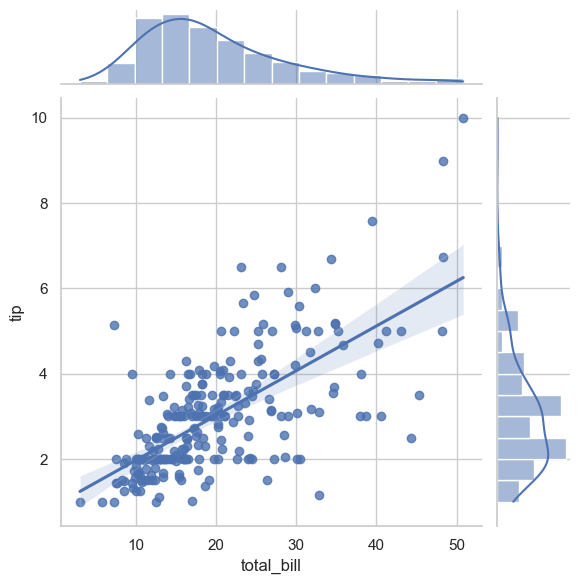

In [168]:
### Solution
sns.jointplot(x='total_bill', y='tip', data=tips, kind='reg')


### Heatmap (Common EDA Pattern)

Heatmaps are useful for compact matrix-style summaries, such as correlation matrices.


Text(0.5, 1.0, 'Correlation Heatmap')

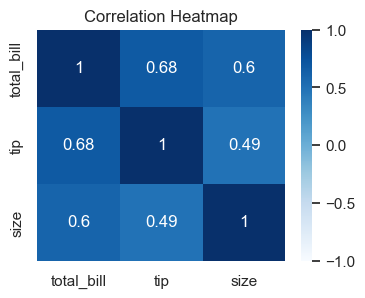

In [170]:
corr = tips[['total_bill', 'tip', 'size']].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Heatmap')


In [ ]:
### Exercise: Correlation Heatmap
#   1. Compute a correlation matrix from ['total_bill', 'tip', 'size'].
#   2. Plot a heatmap with annot=True and cmap='Blues'.
#   3. Set vmin=-1 and vmax=1.
#   4. Add title 'Tips Correlation Heatmap'.
### Your code starts here.




### Your code ends here.


Text(0.5, 1.0, 'Tips Correlation Heatmap')

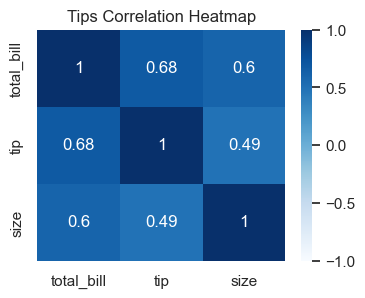

In [ ]:
### Solution
corr = tips[['total_bill', 'tip', 'size']].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1, ax=ax)
ax.set_title('Tips Correlation Heatmap')


## Themes and Global Style

Seaborn theme settings apply globally in the notebook and help keep plots visually consistent.


Seaborn theme settings apply globally in the notebook and help keep plots consistent.

<Axes: xlabel='total_bill', ylabel='tip'>

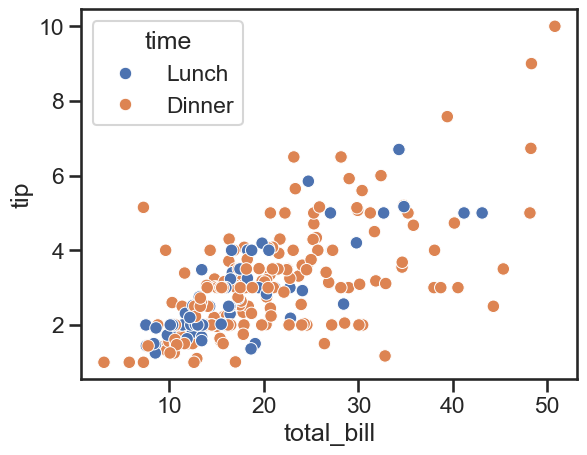

In [172]:
sns.set_theme(style='ticks', context='talk', palette='deep')
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time')


In [173]:
# Reset to a moderate default for the rest of your work
sns.set_theme(style='whitegrid', context='notebook')


## Why KDE Looks Smooth

This section is optional and focuses on intuition for KDE construction.


`rugplot` marks each observation on one axis. A KDE can be viewed as the sum of many smooth kernels centered on those observations.

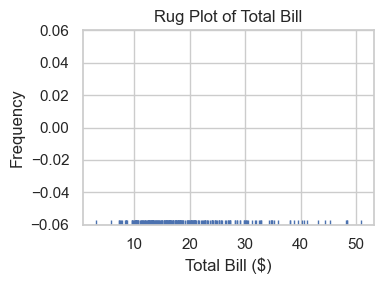

In [174]:
ax = sns.rugplot(tips['total_bill'])
ax.set_title('Rug Plot of Total Bill')
ax.set_xlabel('Total Bill ($)')
ax.set_ylabel('Frequency')

ax.figure.set_size_inches(4, 3)
plt.tight_layout()

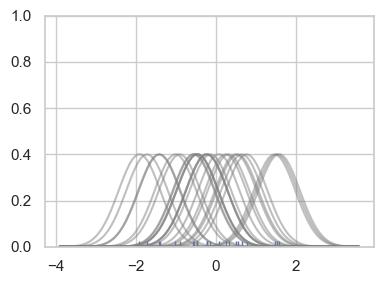

In [175]:
# Don't worry about understanding this code in depth.
# It visualizes how summing basis functions forms a KDE-like curve.
from scipy import stats

# Create dataset
np.random.seed(42)
dataset = np.random.randn(25)

ax = sns.rugplot(dataset)

x_min = dataset.min() - 2
x_max = dataset.max() + 2
x_axis = np.linspace(x_min, x_max, 100)

bandwidth = ((4 * dataset.std()**5) / (3 * len(dataset)))**.2

kernel_list = []
for data_point in dataset:
    kernel = stats.norm(data_point, bandwidth).pdf(x_axis)
    kernel_list.append(kernel)

    kernel = kernel / kernel.max()
    kernel = kernel * .4
    plt.plot(x_axis, kernel, color='grey', alpha=0.5)

plt.ylim(0, 1)

ax.figure.set_size_inches(4, 3)
plt.tight_layout()

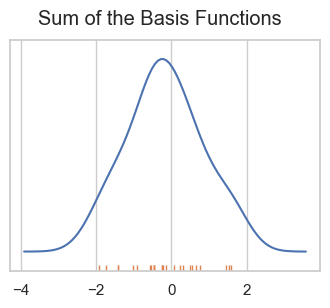

In [176]:
sum_of_kde = np.sum(kernel_list, axis=0)
plt.figure(figsize=(4, 3))
plt.plot(x_axis, sum_of_kde)
sns.rugplot(dataset)
plt.yticks([])
plt.suptitle('Sum of the Basis Functions');

## Styling

### Size

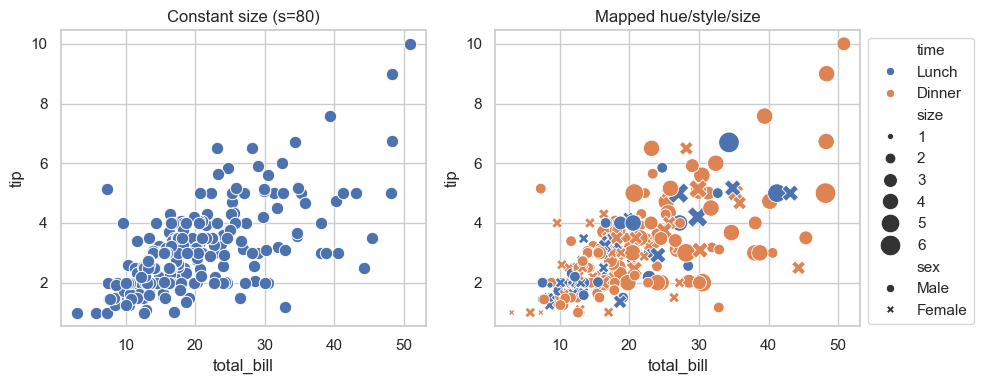

In [177]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# constant size points
sns.scatterplot(data=tips, x='total_bill', y='tip', s=80, ax=ax[0])
ax[0].set_title('Constant size (s=80)')

# size mapped from a real numeric column in the dataframe
sns.scatterplot(
    data=tips, x='total_bill', y='tip',
    hue='time', style='sex', size='size', sizes=(20, 220),
    ax=ax[1]
)
ax[1].set_title('Mapped hue/style/size')
ax[1].legend(bbox_to_anchor=(1, 1))  ### move legend outside the plot

plt.tight_layout()


### Alpha

Seaborn's histplot() automatically sets alpha=0.5 by default when plotting multiple columns. It detects overlapping series and applies transparency automatically so both are visible. That's one of Seaborn's key advantages over Pandas and Matplotlib.

- Pandas plot(kind="hist") — overlaps with no transparency, you have to set alpha= manually
- Matplotlib ax.hist() — same, manual alpha= required
- Seaborn histplot() — handles transparency automatically for overlapping series

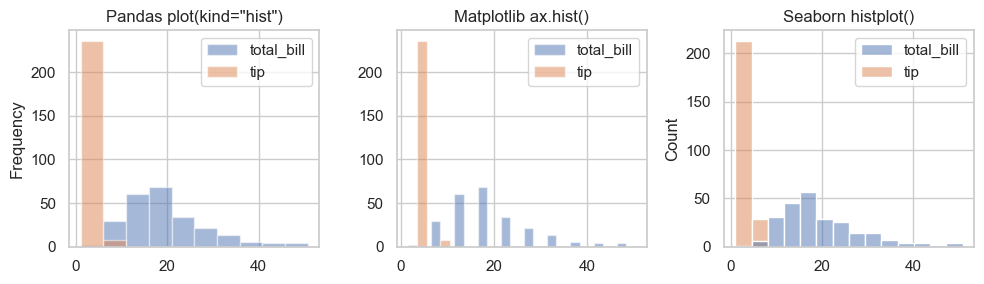

In [178]:
data = tips[['total_bill', 'tip']]

fig, ax = plt.subplots(1, 3, figsize=(10, 3))

### Pandas histogram
data.plot(ax=ax[0], kind='hist', title='Pandas plot(kind="hist")', alpha=0.5)

### Matplotlib histogram
ax[1].hist(data, label=['total_bill', 'tip'], alpha=0.5)
ax[1].set_title('Matplotlib ax.hist()')
ax[1].legend()

### Seaborn histogram
sns.histplot(data=data, ax=ax[2])
ax[2].set_title('Seaborn histplot()')

plt.tight_layout()
